In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [11]:
df = pd.read_csv(r"D:\New folder (2)\End-to-End-Machine-Learning-Project-Implementation\notebooks\data.csv")

In [12]:
df.head()

,What is your age?,What is your gender?,What is your occupation?,Does any member of your family or a close acquaintance live abroad?,Have you decided to move abroad?,How long do you plan to stay abroad?,Are you aware of any specific migration programs or scholarships available for students or workers abroad?,What role do social media and online success stories play in influencing your decision to move abroad?,Who or what influences your decision to move abroad? (Multiple options can be selected),Which countries are you most interested in moving to?,...,What is your primary goal for considering moving abroad? (Multiple options can be selected),What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected),How do you cope with the stress of planning to move abroad?,Do you think migration trends have increased among Bangladeshi youth in the last 5 years?,What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected),Do you think you will return to Bangladesh in the future after living abroad?,Do you think your decision to move abroad will impact your family or community in Bangladesh?,Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?,Do you feel a sense of responsibility towards your family while planning to move abroad?,"How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely)."
0,31-40,Male,Unemployed,No,Not sure yet,Permanently,Yes,No role at all,Personal research and aspirations;Career mento...,USA,...,Other;Desire for independence;Economic opportu...,Visa or immigration concerns;Cultural shock;Se...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Not sure,Positive impact,No,Yes,1
1,18-24,Male,Student,Yes,Yes,3-5 years,Yes,No role at all,Family pressure or support;Personal research a...,USA,...,Better living standards;Higher education;Desir...,Job uncertainty;Other;Visa or immigration conc...,Hobbies or physical exercise,I’m not sure,Other;Financial issues;Family pressure or support,Not sure,Negative impact,Not Sure,Yes,5
2,31-40,Female,Other,Yes,No,Permanently,Maybe,A significant role,Personal research and aspirations;Friends or p...,UK,...,Political stability;Economic opportunities;Hig...,Social acceptance;Visa or immigration concerns...,Joining online forums,No change,Educational qualification;Job information or e...,Yes,No impact,Not Sure,Maybe,5
3,25-30,Male,Employed,Yes,No,Permanently,Yes,A significant role,Social media and online success stories;Other;...,"Europe (e.g., Germany, Sweden)",...,Economic opportunities;Political stability;Des...,Other;Cultural shock;Visa or immigration concerns,Talking to family and friends,I’m not sure,Other;Financial issues;Job information or expe...,Yes,Positive impact,Not Sure,No,3
4,40 or above,Male,Self-employed,Yes,Yes,3-5 years,No,A significant role,Other;Personal research and aspirations;Friend...,Canada,...,Better job opportunities;Better living standar...,Visa or immigration concerns;Other;Separation ...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Yes,Negative impact,Not Sure,No,2


In [13]:
df.shape

(2614, 21)

In [14]:
# Display summary statistics for a dataframe
df.describe()

,"How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely)."
count,2614.000000
mean,2.956006
std,1.510258
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [15]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2614 entries, 0 to 2613
Data columns (total 21 columns):
 #   Column                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                 --------------  ----- 
 0   What is your age?                                                                                                                                      2614 non-null   object
 1   What is your gender?                                                                                                                                   2614 non-null   object
 2   What is your occupation?                                                                                                                               2614 non-null   objec

### EXPLORING DATA

In [16]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 1 numerical features : ['How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).']

We have 20 categorical features : ['What is your age?', 'What is your gender?  ', 'What is your occupation?  ', 'Does any member of your family or a close acquaintance live abroad?', 'Have you decided to move abroad?', 'How long do you plan to stay abroad?', 'Are you aware of any specific migration programs or scholarships available for students or workers abroad?  ', 'What role do social media and online success stories play in influencing your decision to move abroad?', 'Who or what influences your decision to move abroad? (Multiple options can be selected)', 'Which countries are you most interested in moving to?', 'How much psychological stress or anxiety have you experienced while considering moving abroad?  ', 'What is your primary goal for considering moving abroad? (Multiple options can be select

In [17]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

What is your age?
25-30          28.309105
31-40          25.172150
40 or above    23.603673
18-24          22.915073
Name: proportion, dtype: float64
---------------------------
What is your gender?  
Male      53.978577
Female    46.021423
Name: proportion, dtype: float64
---------------------------
What is your occupation?  
Student          27.620505
Self-employed    22.188217
Employed         20.428462
Unemployed       13.657230
Freelancer       10.290742
Other             5.814843
Name: proportion, dtype: float64
---------------------------
Does any member of your family or a close acquaintance live abroad?
No     54.016832
Yes    45.983168
Name: proportion, dtype: float64
---------------------------
Have you decided to move abroad?
No              45.294568
Yes             31.407804
Not sure yet    23.297628
Name: proportion, dtype: float64
---------------------------
How long do you plan to stay abroad?
Less than 1 year    38.446825
Permanently         32.249426
3-5 years      

### Numerical Features

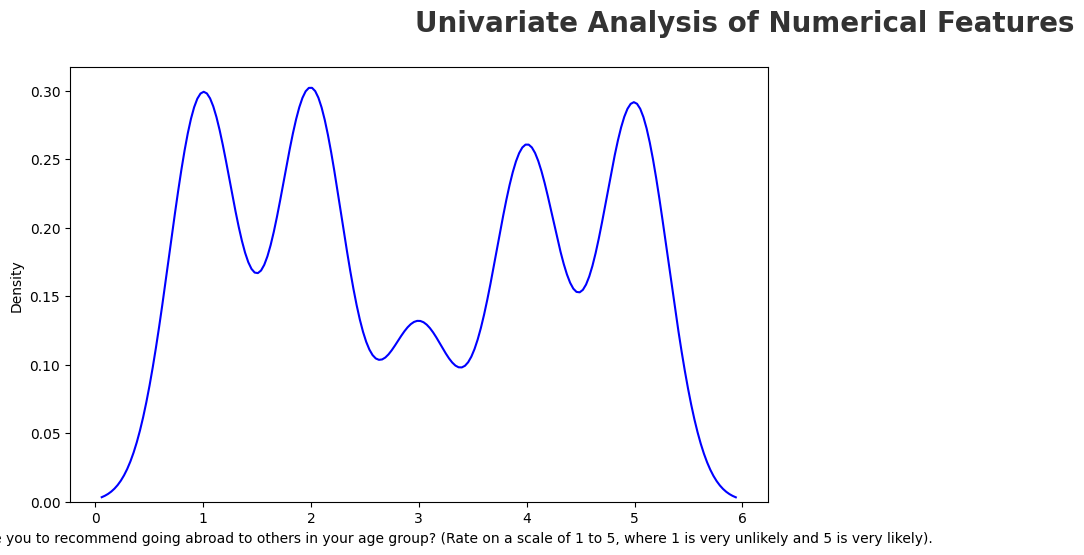

In [18]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()
    
# save plot
# plt.savefig('./images/Univariate_Num.png')

### Categorical Features

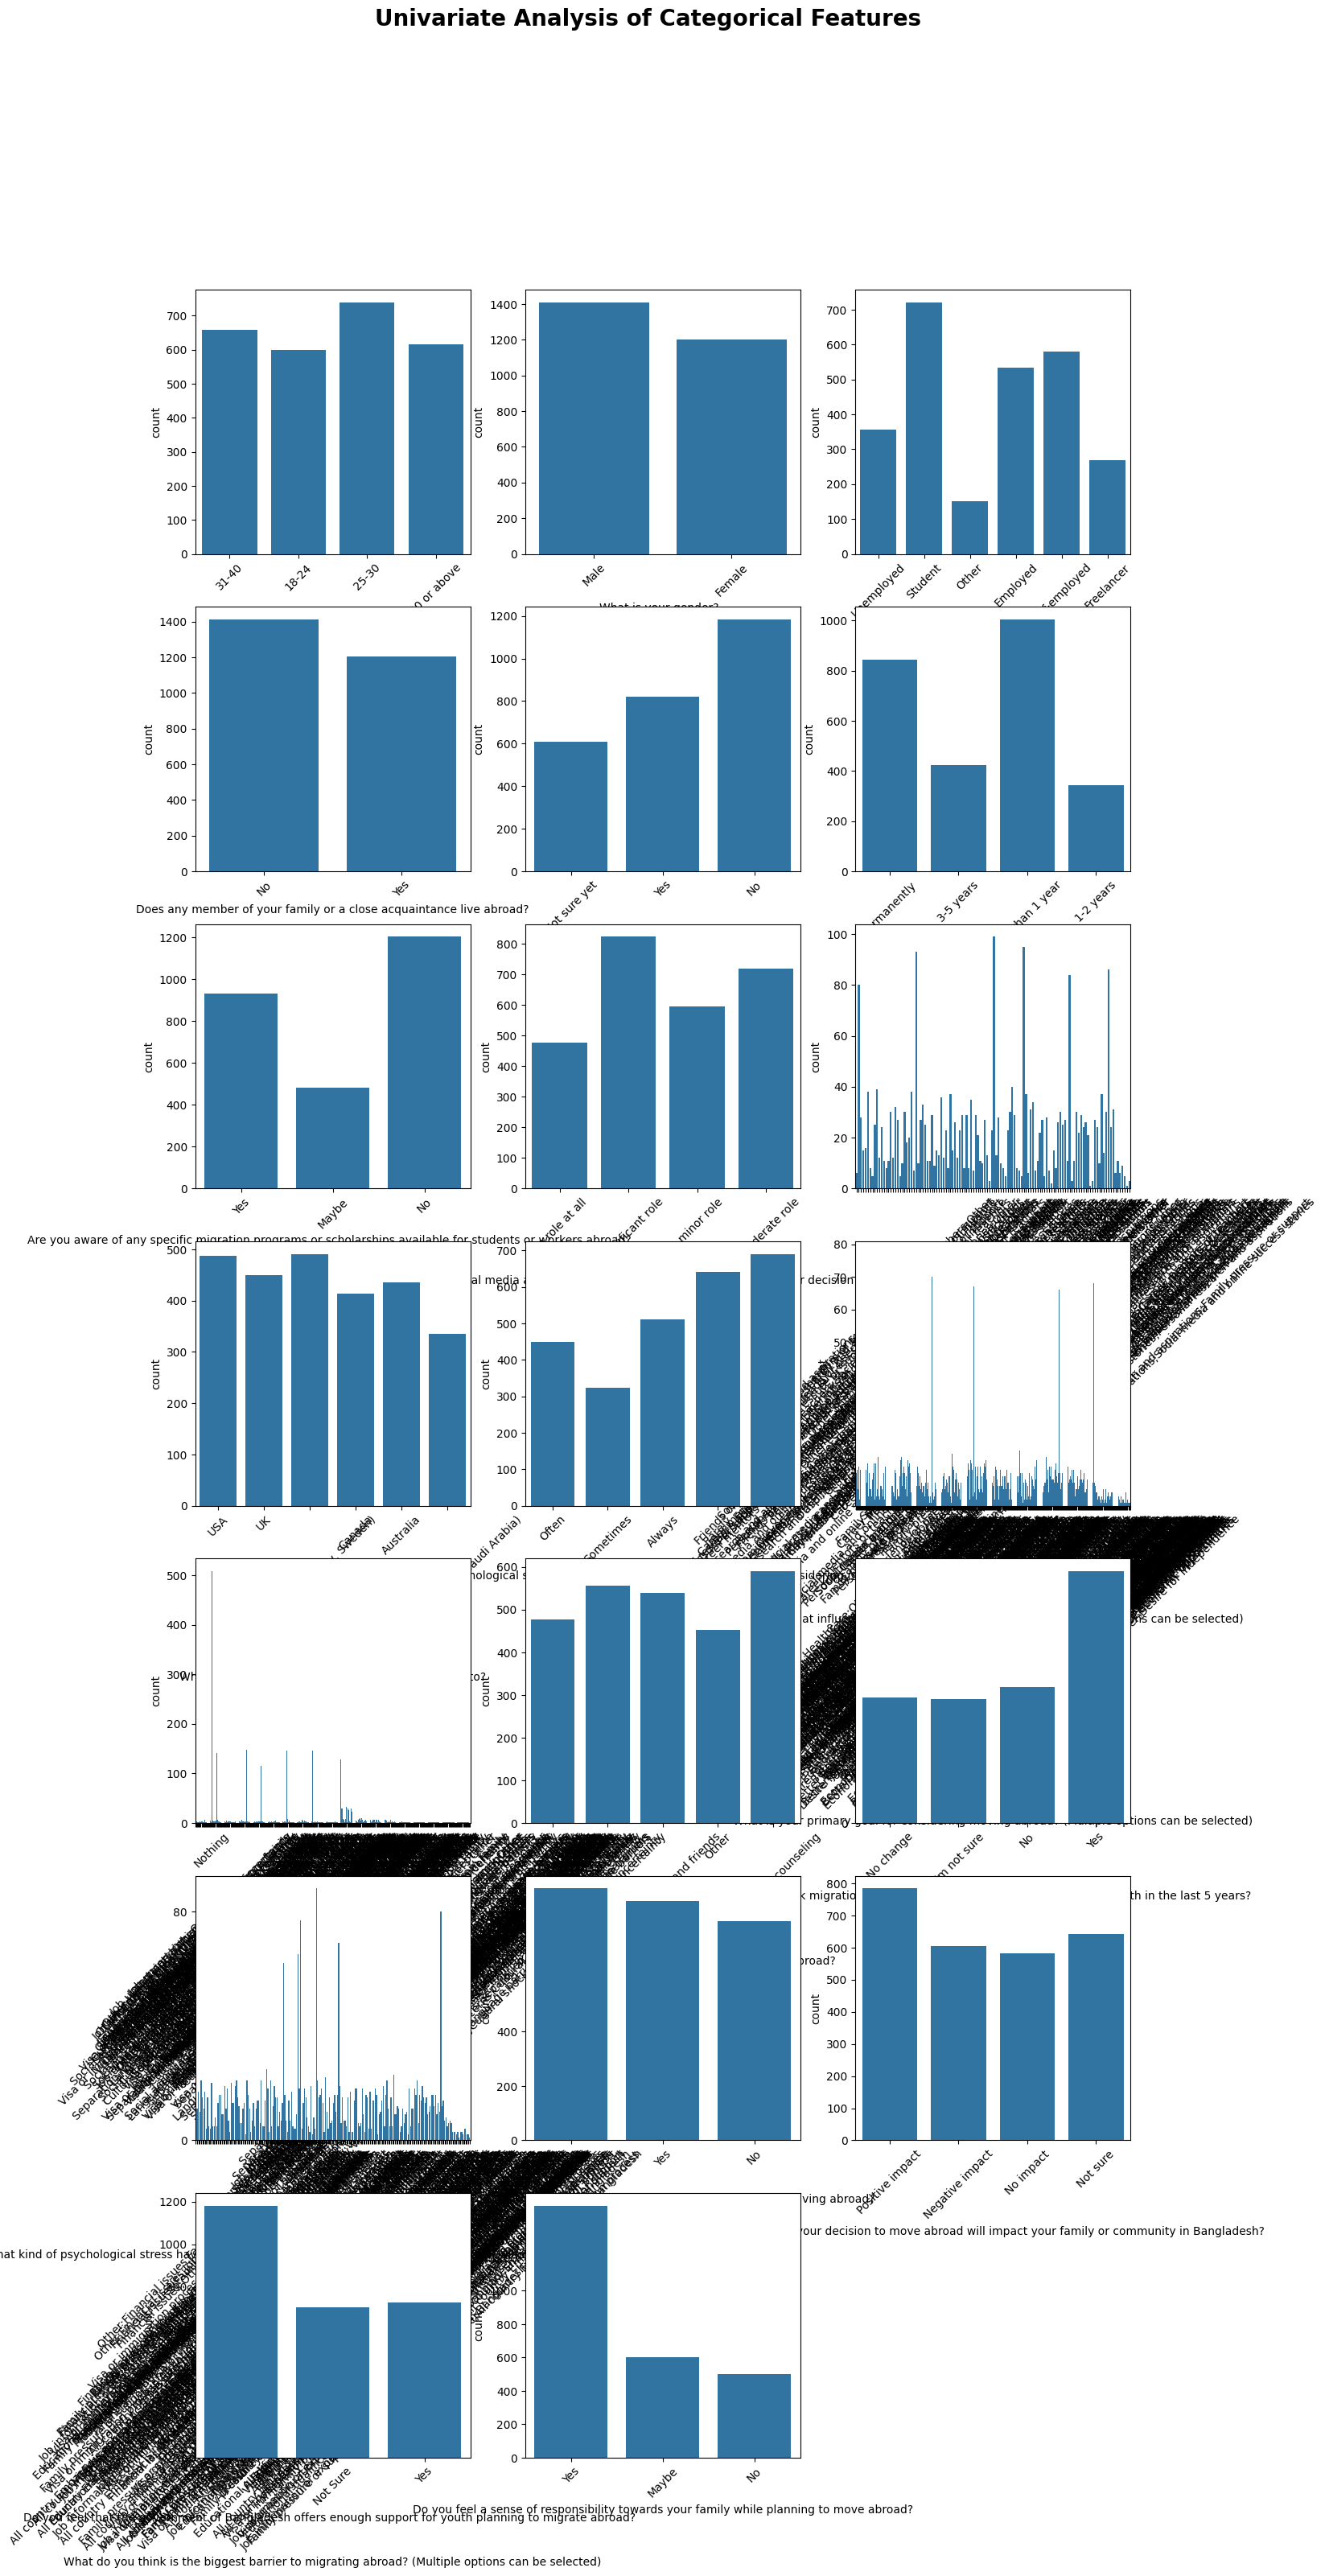

In [21]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# remove 'case_id' safely (if exists)
categorical_features = [col for col in categorical_features if col != 'case_id']

# number of features
n = len(categorical_features)

# grid size
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))
plt.suptitle('Univariate Analysis of Categorical Features',
             fontsize=20, fontweight='bold')

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Multivariate Analysis

In [24]:
discrete_features=[feature for feature in numeric_features if len(df[feature].unique())<=25]

continuous_features=[feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features : {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous_features : {}'.format(len(continuous_features), continuous_features))

We have 1 discrete features : ['How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely).']

We have 0 continuous_features : []


### Check Multicollinearity in Numerical features

In [25]:
df.head()

,What is your age?,What is your gender?,What is your occupation?,Does any member of your family or a close acquaintance live abroad?,Have you decided to move abroad?,How long do you plan to stay abroad?,Are you aware of any specific migration programs or scholarships available for students or workers abroad?,What role do social media and online success stories play in influencing your decision to move abroad?,Who or what influences your decision to move abroad? (Multiple options can be selected),Which countries are you most interested in moving to?,...,What is your primary goal for considering moving abroad? (Multiple options can be selected),What kind of psychological stress have you experienced while planning to move abroad? (Multiple options can be selected),How do you cope with the stress of planning to move abroad?,Do you think migration trends have increased among Bangladeshi youth in the last 5 years?,What do you think is the biggest barrier to migrating abroad? (Multiple options can be selected),Do you think you will return to Bangladesh in the future after living abroad?,Do you think your decision to move abroad will impact your family or community in Bangladesh?,Do you feel that the government of Bangladesh offers enough support for youth planning to migrate abroad?,Do you feel a sense of responsibility towards your family while planning to move abroad?,"How likely are you to recommend going abroad to others in your age group? (Rate on a scale of 1 to 5, where 1 is very unlikely and 5 is very likely)."
0,31-40,Male,Unemployed,No,Not sure yet,Permanently,Yes,No role at all,Personal research and aspirations;Career mento...,USA,...,Other;Desire for independence;Economic opportu...,Visa or immigration concerns;Cultural shock;Se...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Not sure,Positive impact,No,Yes,1
1,18-24,Male,Student,Yes,Yes,3-5 years,Yes,No role at all,Family pressure or support;Personal research a...,USA,...,Better living standards;Higher education;Desir...,Job uncertainty;Other;Visa or immigration conc...,Hobbies or physical exercise,I’m not sure,Other;Financial issues;Family pressure or support,Not sure,Negative impact,Not Sure,Yes,5
2,31-40,Female,Other,Yes,No,Permanently,Maybe,A significant role,Personal research and aspirations;Friends or p...,UK,...,Political stability;Economic opportunities;Hig...,Social acceptance;Visa or immigration concerns...,Joining online forums,No change,Educational qualification;Job information or e...,Yes,No impact,Not Sure,Maybe,5
3,25-30,Male,Employed,Yes,No,Permanently,Yes,A significant role,Social media and online success stories;Other;...,"Europe (e.g., Germany, Sweden)",...,Economic opportunities;Political stability;Des...,Other;Cultural shock;Visa or immigration concerns,Talking to family and friends,I’m not sure,Other;Financial issues;Job information or expe...,Yes,Positive impact,Not Sure,No,3
4,40 or above,Male,Self-employed,Yes,Yes,3-5 years,No,A significant role,Other;Personal research and aspirations;Friend...,Canada,...,Better job opportunities;Better living standar...,Visa or immigration concerns;Other;Separation ...,Hobbies or physical exercise,No change,Job information or experience;Other;All countr...,Yes,Negative impact,Not Sure,No,2


### Check Multicollinearity for Categorical features

In [35]:
!pip install scipy

  Using cached scipy-1.10.1-cp38-cp38-win_amd64.whl.metadata (58 kB)
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/42.2 MB ? eta -:--:--
   ------------------

In [41]:
import pandas as pd
from scipy.stats import chi2_contingency

# 🔹 Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 🔹 Step 2: Set target column (CHANGE HERE if needed)
target = 'have_you_decided_to_move_abroad?'

# 🔹 Step 3: Check target exists
if target not in df.columns:
    raise ValueError(f"Target column not found. Available columns: {list(df.columns)}")

# 🔹 Step 4: Select categorical features (excluding target)
categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != target]

# 🔹 Step 5: Chi-Square Test
chi2_test = []

for feature in categorical_features:
    
    if df[feature].nunique() < 2:
        chi2_test.append('Not Applicable')
        continue

    table = pd.crosstab(df[target], df[feature])

    if table.shape[0] < 2 or table.shape[1] < 2:
        chi2_test.append('Not Applicable')
        continue

    p_value = chi2_contingency(table)[1]

    if p_value < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

# 🔹 Step 6: Result
result = pd.DataFrame({
    'Column': categorical_features,
    'Hypothesis Result': chi2_test
})

result

,Column,Hypothesis Result
0,what_is_your_age?,Reject Null Hypothesis
1,what_is_your_gender?,Reject Null Hypothesis
2,what_is_your_occupation?,Reject Null Hypothesis
3,does_any_member_of_your_family_or_a_close_acqu...,Reject Null Hypothesis
4,how_long_do_you_plan_to_stay_abroad?,Reject Null Hypothesis
5,are_you_aware_of_any_specific_migration_progra...,Reject Null Hypothesis
6,what_role_do_social_media_and_online_success_s...,Reject Null Hypothesis
7,who_or_what_influences_your_decision_to_move_a...,Reject Null Hypothesis
8,which_countries_are_you_most_interested_in_mov...,Fail to Reject Null Hypothesis
9,how_much_psychological_stress_or_anxiety_have_...,Reject Null Hypothesis


In [42]:
df.isnull().sum()

what_is_your_age?                                                                                                                                        0
what_is_your_gender?                                                                                                                                     0
what_is_your_occupation?                                                                                                                                 0
does_any_member_of_your_family_or_a_close_acquaintance_live_abroad?                                                                                      0
have_you_decided_to_move_abroad?                                                                                                                         0
how_long_do_you_plan_to_stay_abroad?                                                                                                                     0
are_you_aware_of_any_specific_migration_programs_or_scholarships_avail

In [44]:
import pandas as pd
from scipy.stats import chi2_contingency

# ================================
# 🔹 Step 1: Clean column names
# ================================
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ================================
# 🔹 Step 2: Define target column
# ================================
target = 'have_you_decided_to_move_abroad?'

if target not in df.columns:
    raise ValueError(f"Target column not found.\nAvailable columns:\n{list(df.columns)}")

# ================================
# 🔹 Step 3: Separate features
# ================================
categorical_features = df.select_dtypes(include='object').columns.tolist()
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target from features
categorical_features = [col for col in categorical_features if col != target]

# ================================
# 🔹 Step 4: Continuous features
# ================================
continuous_features = [
    feature for feature in numeric_features
    if df[feature].nunique() >= 10
]

print("Continuous Features:", continuous_features)

# ================================
# 🔹 Step 5: Chi-Square Test
# ================================
chi2_test = []

for feature in categorical_features:
    
    # Skip invalid columns
    if df[feature].nunique() < 2:
        chi2_test.append('Not Applicable')
        continue

    table = pd.crosstab(df[target], df[feature])

    # Skip invalid tables
    if table.shape[0] < 2 or table.shape[1] < 2:
        chi2_test.append('Not Applicable')
        continue

    p_value = chi2_contingency(table)[1]

    if p_value < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

# ================================
# 🔹 Step 6: Result DataFrame
# ================================
result = pd.DataFrame({
    'Feature': categorical_features,
    'Chi2 Result': chi2_test
})

print(result)

Continuous Features: []
                                              Feature  \
0                                   what_is_your_age?   
1                                what_is_your_gender?   
2                            what_is_your_occupation?   
3   does_any_member_of_your_family_or_a_close_acqu...   
4                how_long_do_you_plan_to_stay_abroad?   
5   are_you_aware_of_any_specific_migration_progra...   
6   what_role_do_social_media_and_online_success_s...   
7   who_or_what_influences_your_decision_to_move_a...   
8   which_countries_are_you_most_interested_in_mov...   
9   how_much_psychological_stress_or_anxiety_have_...   
10  what_is_your_primary_goal_for_considering_movi...   
11  what_kind_of_psychological_stress_have_you_exp...   
12  how_do_you_cope_with_the_stress_of_planning_to...   
13  do_you_think_migration_trends_have_increased_a...   
14  what_do_you_think_is_the_biggest_barrier_to_mi...   
15  do_you_think_you_will_return_to_bangladesh_in_...   
16  do_

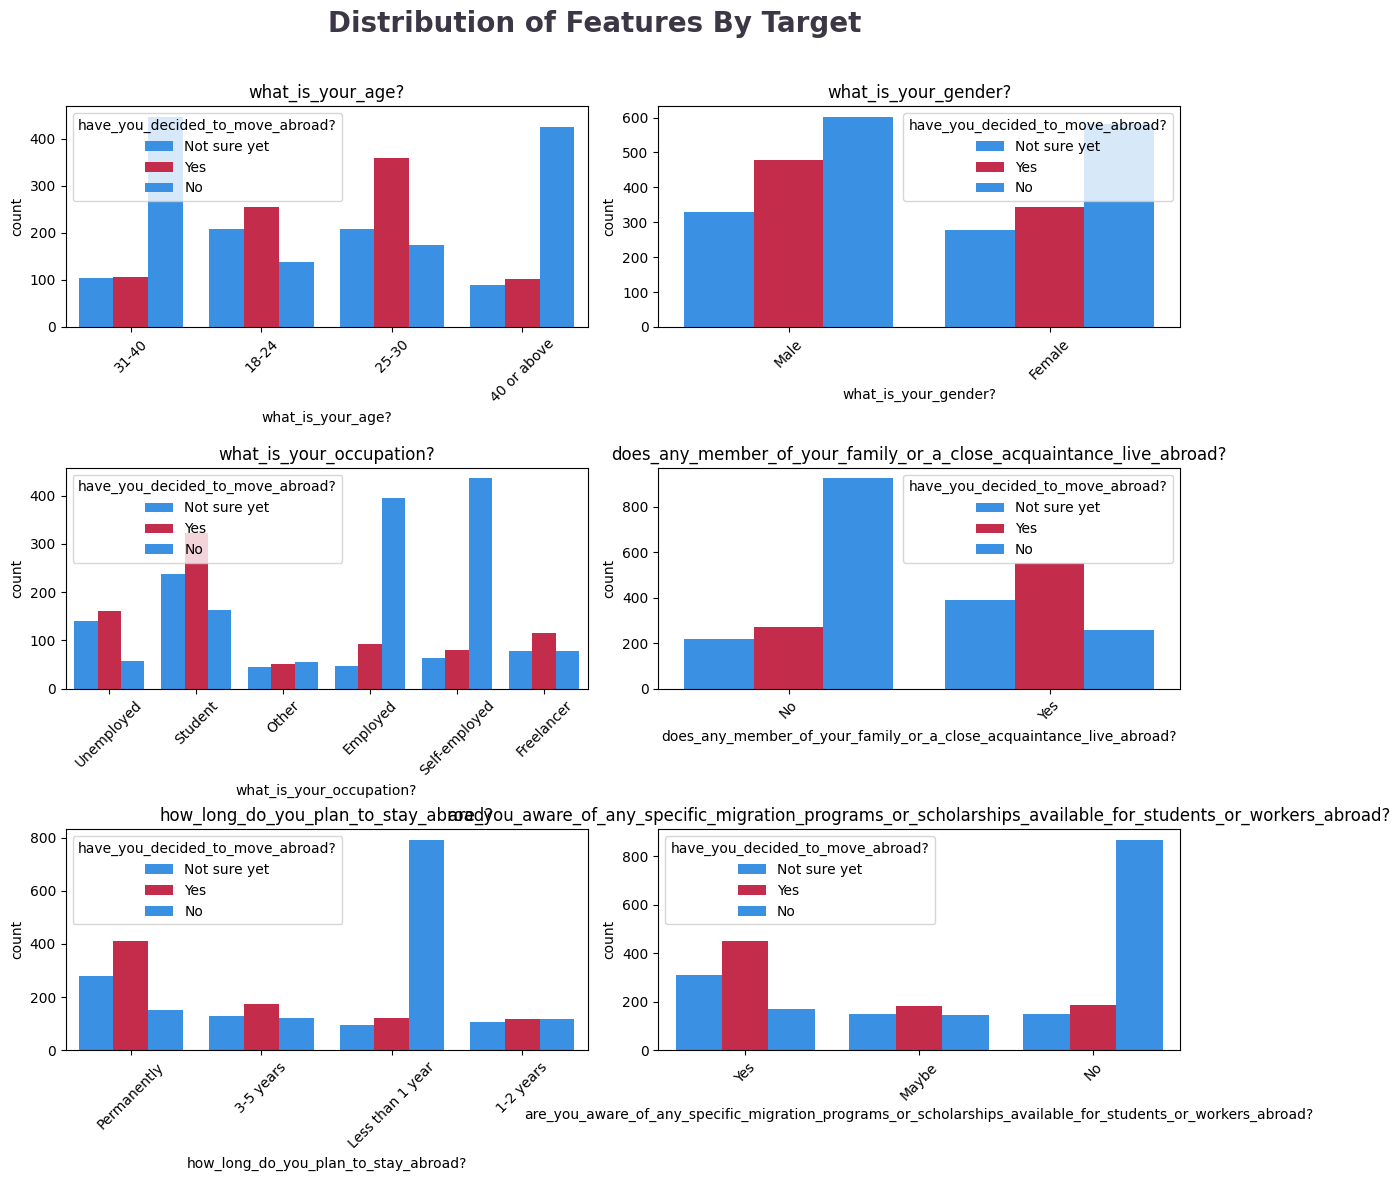

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 🔹 Step 2: Correct target column
target = 'have_you_decided_to_move_abroad?'

# 🔹 Step 3: Get categorical features
categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != target]

# 🔹 Step 4: Plot (same grid style like your code)
clr1 = ['#1E90FF', '#DC143C']

fig, ax = plt.subplots(3, 2, figsize=(12,12))
fig.suptitle('Distribution of Features By Target', color='#3C3744',
             fontsize=20, fontweight='bold')

# take first 6 features (because 3x2 grid)
for i, col in enumerate(categorical_features[:6]):

    row = i // 2
    col_idx = i % 2

    sns.countplot(data=df, x=col, hue=target, palette=clr1, ax=ax[row, col_idx])
    ax[row, col_idx].set_title(f'{col}', fontsize=12)
    ax[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

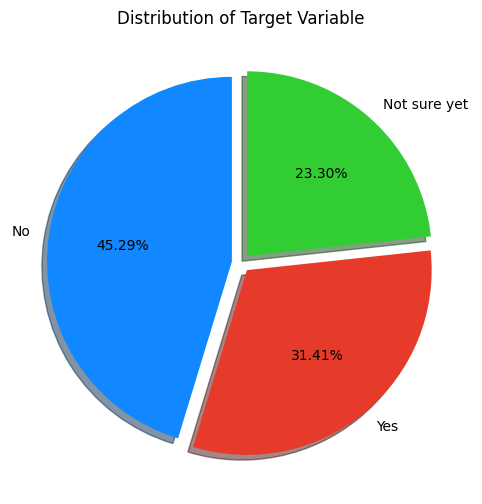

In [53]:
import matplotlib.pyplot as plt

# 🔹 Step 1: Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# 🔹 Step 2: Correct target column
target = 'have_you_decided_to_move_abroad?'

# 🔹 Step 3: Calculate percentage
percentage = df[target].value_counts(normalize=True) * 100

# 🔹 Step 4: Labels (auto নেওয়া)
labels = percentage.index.tolist()

# 🔹 Step 5: Plot
fig, ax = plt.subplots(figsize=(8,6))

explode = [0.05] * len(labels)   # dynamic explode
colors = ['#1188ff', '#e63a2a', '#32cd32']  # extra color safe

ax.pie(
    percentage,
    labels=labels,
    startangle=90,
    autopct='%1.2f%%',
    explode=explode[:len(labels)],
    shadow=True,
    colors=colors[:len(labels)]
)

ax.set_title('Distribution of Target Variable')

plt.show()

In [55]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

df.groupby('continent')['have_you_decided_to_move_abroad?'] \
  .value_counts(normalize=True) \
  .to_frame() * 100

proportion
continent     have_you_decided_to_move_abroad?            
Australia     No                                 44.954128
              Yes                                32.339450
              Not sure yet                       22.706422
Europe        No                                 45.802338
              Yes                                31.880978
              Not sure yet                       22.316684
Middle East   No                                 49.552239
              Yes                                25.671642
              Not sure yet                       24.776119
North America No                                 43.348115
              Yes                                32.594235
              Not sure yet                       24.057650

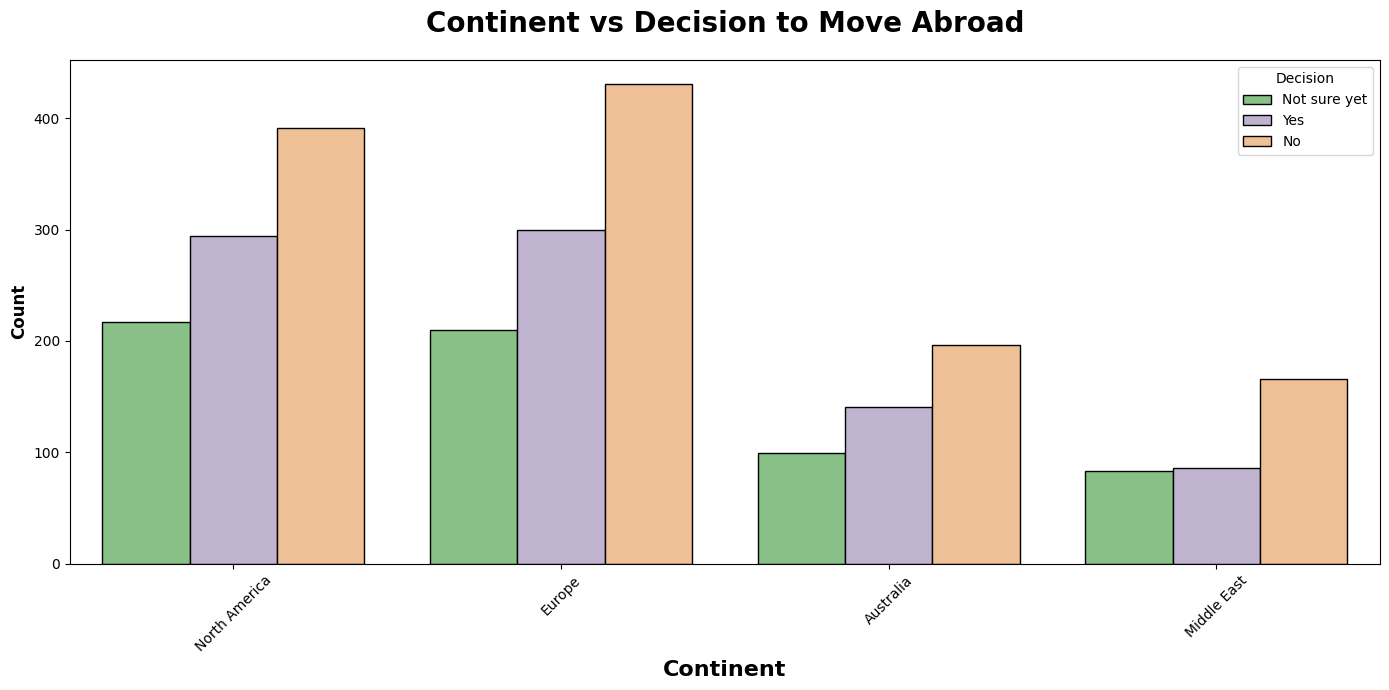

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# correct target
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

sns.countplot(
    x='continent',
    hue=target,
    data=df,
    edgecolor="black",
    palette="Accent"
)

plt.title("Continent vs Decision to Move Abroad", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Continent", weight="bold", fontsize=16)
plt.xticks(rotation=45)

plt.legend(title="Decision", fancybox=True)

plt.tight_layout()
plt.show()

In [57]:
df2 = df.copy()

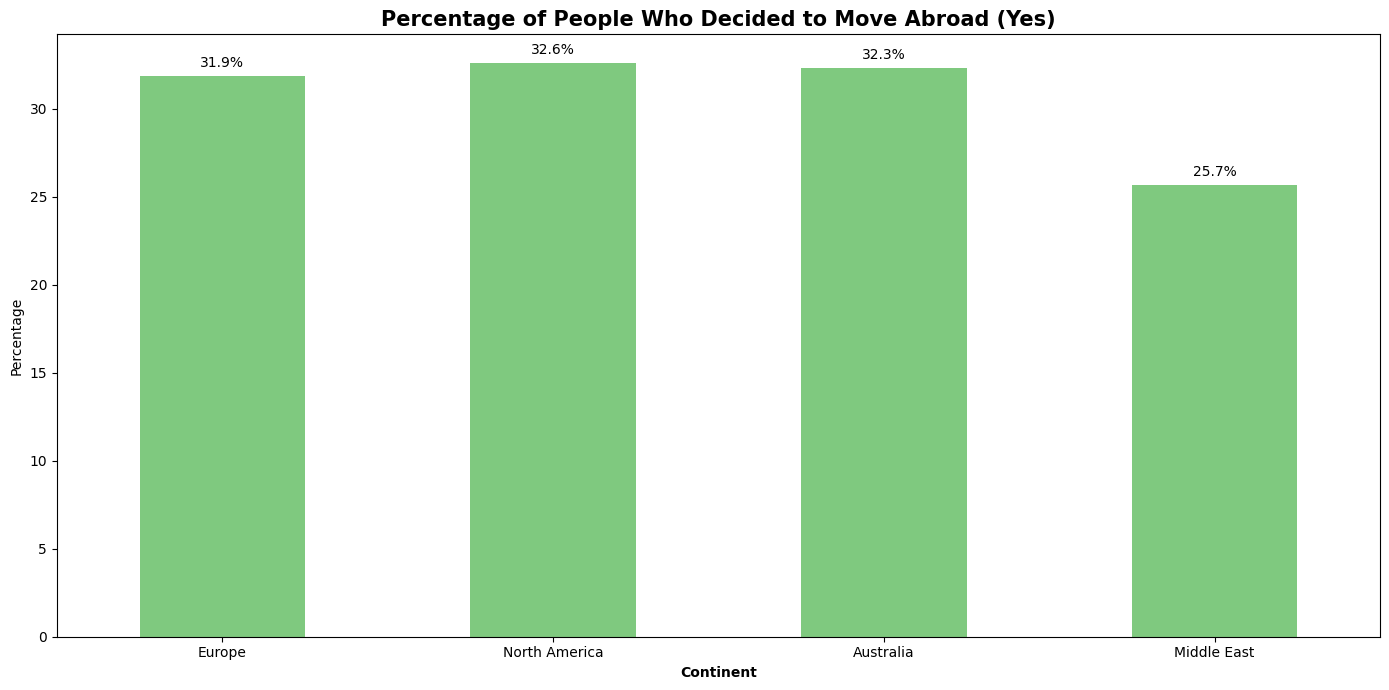

In [58]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# target column
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes']['continent'].value_counts() /
    df['continent'].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of People Who Decided to Move Abroad (Yes)", 
          fontsize=15, fontweight='bold')

# add text labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Continent', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [59]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'what_is_your_occupation?'
target = 'have_you_decided_to_move_abroad?'

# groupby percentage
result = (
    df.groupby(feature)[target]
    .value_counts(normalize=True)
    .mul(100)
    .to_frame(name='percentage')
)

print(result)

                                                           percentage
what_is_your_occupation? have_you_decided_to_move_abroad?            
Employed                 No                                 73.970037
                         Yes                                17.228464
                         Not sure yet                        8.801498
Freelancer               Yes                                42.750929
                         No                                 28.624535
                         Not sure yet                       28.624535
Other                    No                                 36.842105
                         Yes                                33.552632
                         Not sure yet                       29.605263
Self-employed            No                                 75.172414
                         Yes                                13.965517
                         Not sure yet                       10.862069
Student             

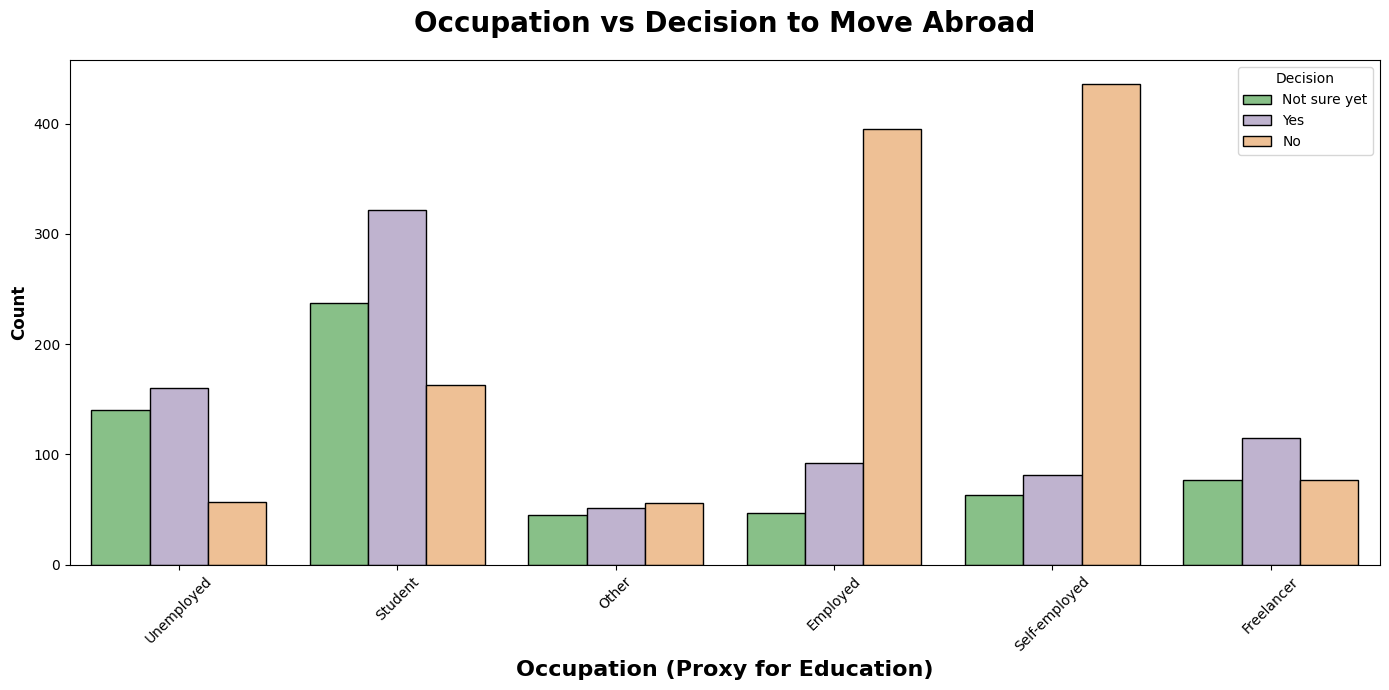

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# correct columns
feature = 'what_is_your_occupation?'
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

sns.countplot(
    x=feature,
    hue=target,
    data=df,
    edgecolor="black",
    palette="Accent"
)

plt.title("Occupation vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Occupation (Proxy for Education)", weight="bold", fontsize=16)

plt.xticks(rotation=45)
plt.legend(title="Decision", fancybox=True)

plt.tight_layout()
plt.show()

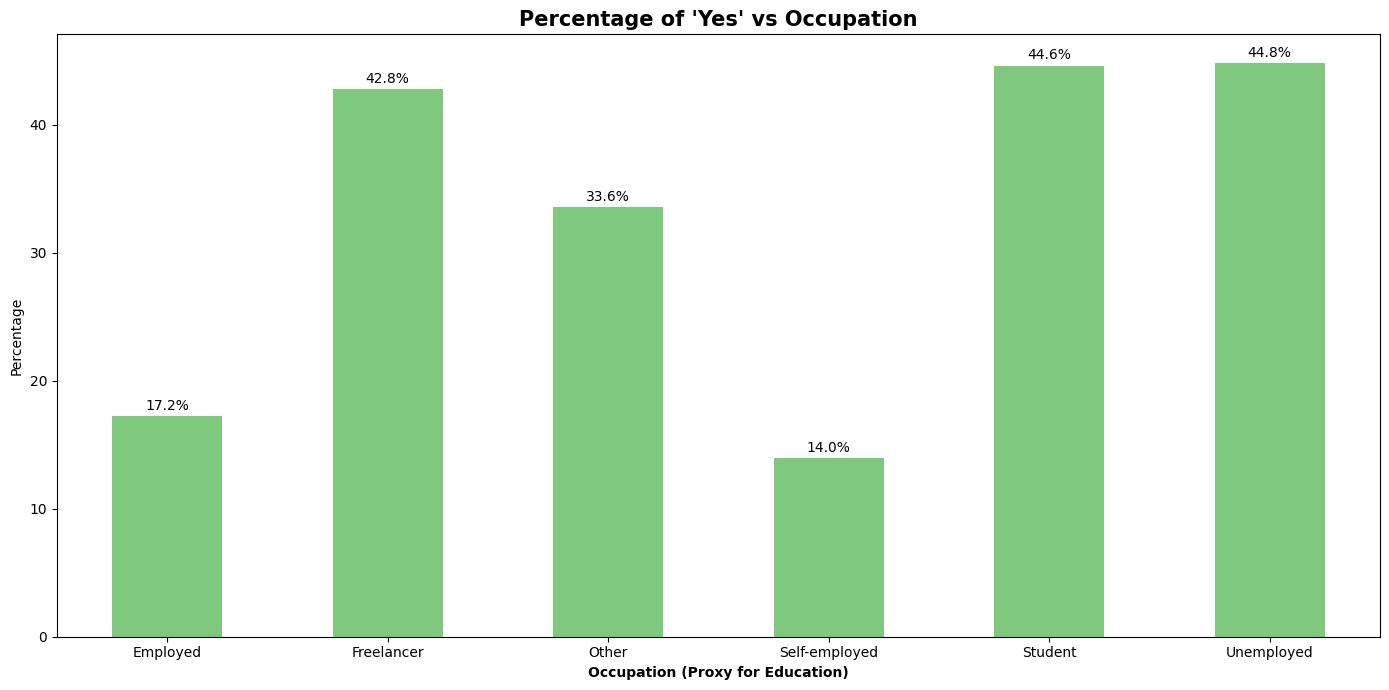

In [61]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
target = 'have_you_decided_to_move_abroad?'
feature = 'what_is_your_occupation?'

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes'][feature].value_counts() /
    df[feature].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of 'Yes' vs Occupation",
          fontsize=15, fontweight='bold')

# add labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Occupation (Proxy for Education)', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [62]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'what_is_your_occupation?'   # proxy for experience
target = 'have_you_decided_to_move_abroad?'

# groupby percentage
result = (
    df.groupby(feature)[target]
    .value_counts(normalize=True)
    .mul(100)
    .to_frame(name='percentage')
)

print(result)

                                                           percentage
what_is_your_occupation? have_you_decided_to_move_abroad?            
Employed                 No                                 73.970037
                         Yes                                17.228464
                         Not sure yet                        8.801498
Freelancer               Yes                                42.750929
                         No                                 28.624535
                         Not sure yet                       28.624535
Other                    No                                 36.842105
                         Yes                                33.552632
                         Not sure yet                       29.605263
Self-employed            No                                 75.172414
                         Yes                                13.965517
                         Not sure yet                       10.862069
Student             

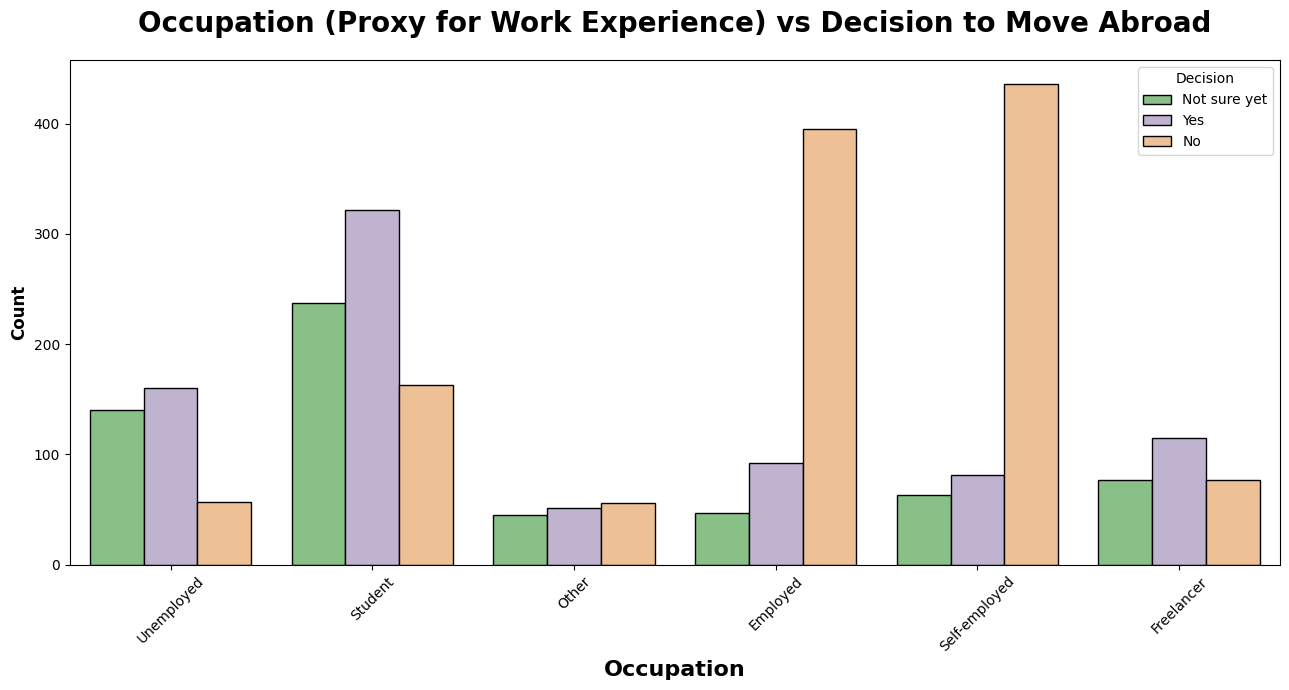

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# proxy for experience
feature = 'what_is_your_occupation?'
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(13,7))

sns.countplot(
    x=feature,
    hue=target,
    data=df,
    edgecolor="black",
    palette="Accent"
)

plt.title("Occupation (Proxy for Work Experience) vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Occupation", weight="bold", fontsize=16)

plt.xticks(rotation=45)
plt.legend(title="Decision", fancybox=True)

plt.tight_layout()
plt.show()

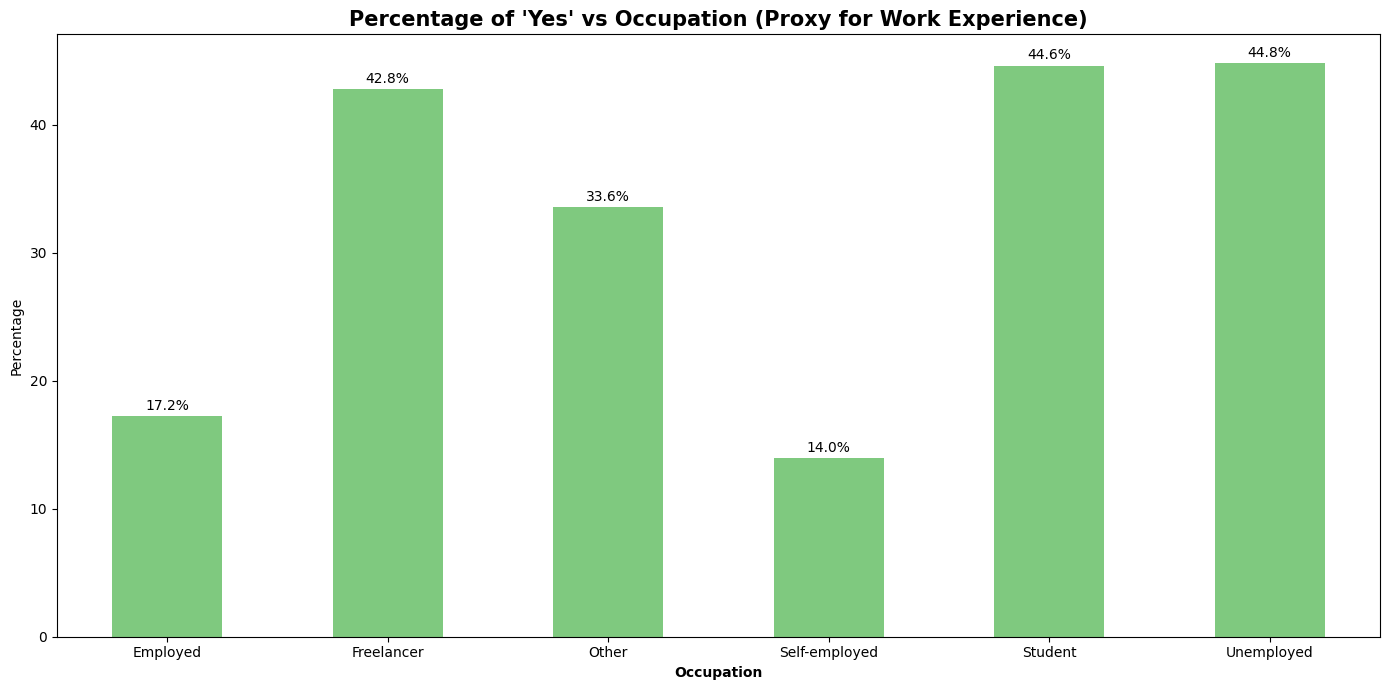

In [64]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
target = 'have_you_decided_to_move_abroad?'
feature = 'what_is_your_occupation?'   # proxy for work experience

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes'][feature].value_counts() /
    df[feature].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of 'Yes' vs Occupation (Proxy for Work Experience)",
          fontsize=15, fontweight='bold')

# add labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Occupation', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [65]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'how_do_you_cope_with_the_stress_of_planning_to_move_abroad?'
target = 'have_you_decided_to_move_abroad?'

# groupby percentage
result = (
    df.groupby(feature)[target]
    .value_counts(normalize=True)
    .mul(100)
    .to_frame(name='percentage')
)

print(result)

                                                                                     percentage
how_do_you_cope_with_the_stress_of_planning_to_... have_you_decided_to_move_abroad?            
Hobbies or physical exercise                       No                                 45.283019
                                                   Not sure yet                       28.301887
                                                   Yes                                26.415094
Joining online forums                              No                                 44.244604
                                                   Yes                                32.194245
                                                   Not sure yet                       23.561151
Other                                              No                                 49.778761
                                                   Yes                                27.433628
                                        

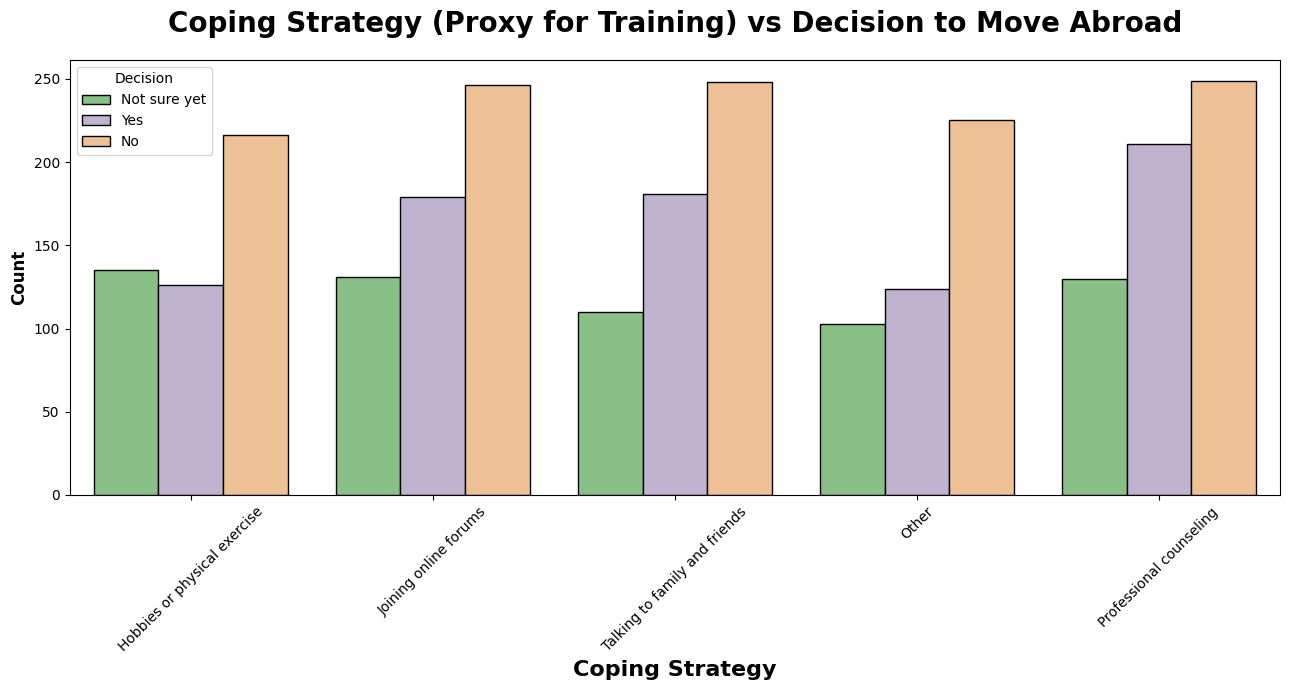

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# proxy feature + target
feature = 'how_do_you_cope_with_the_stress_of_planning_to_move_abroad?'
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(13,7))

sns.countplot(
    x=feature,
    hue=target,
    data=df,
    edgecolor="black",
    palette="Accent"
)

plt.title("Coping Strategy (Proxy for Training) vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Coping Strategy", weight="bold", fontsize=16)

plt.xticks(rotation=45)
plt.legend(title="Decision", fancybox=True)

plt.tight_layout()
plt.show()

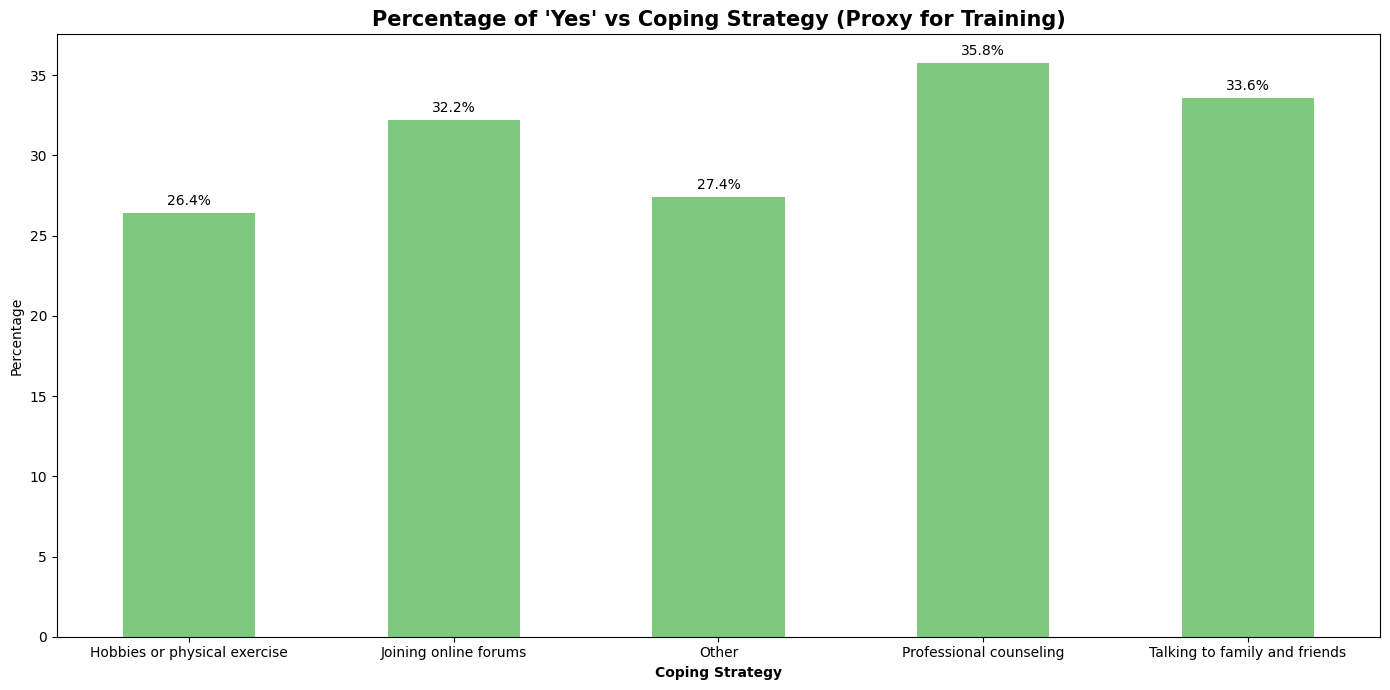

In [67]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# proxy feature + target
feature = 'how_do_you_cope_with_the_stress_of_planning_to_move_abroad?'
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes'][feature].value_counts() /
    df[feature].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of 'Yes' vs Coping Strategy (Proxy for Training)",
          fontsize=15, fontweight='bold')

# add labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Coping Strategy', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

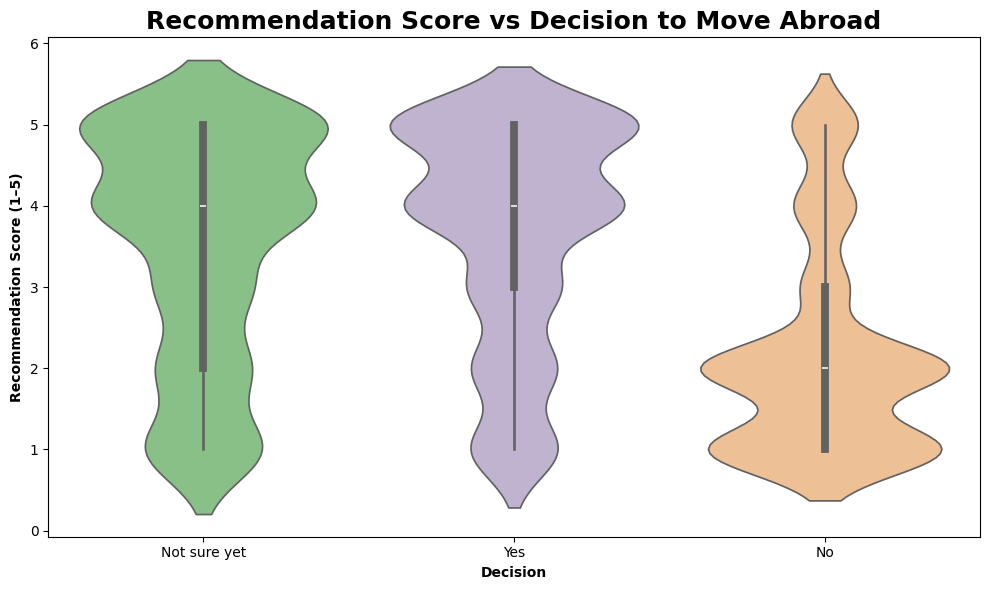

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define target + numeric feature
target = 'have_you_decided_to_move_abroad?'
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

plt.figure(figsize=(10,6))

sns.violinplot(
    x=target,
    y=num_feature,
    data=df,
    palette="Accent"
)

plt.title("Recommendation Score vs Decision to Move Abroad",
          weight="bold", fontsize=18)

plt.ylabel("Recommendation Score (1–5)", weight="bold")
plt.xlabel("Decision", weight="bold")

plt.tight_layout()
plt.show()

In [69]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

feature = 'what_is_your_occupation?'
target = 'have_you_decided_to_move_abroad?'

df.groupby(feature)[target] \
  .value_counts(normalize=True) \
  .mul(100)

what_is_your_occupation?  have_you_decided_to_move_abroad?
Employed                  No                                  73.970037
                          Yes                                 17.228464
                          Not sure yet                         8.801498
Freelancer                Yes                                 42.750929
                          No                                  28.624535
                          Not sure yet                        28.624535
Other                     No                                  36.842105
                          Yes                                 33.552632
                          Not sure yet                        29.605263
Self-employed             No                                  75.172414
                          Yes                                 13.965517
                          Not sure yet                        10.862069
Student                   Yes                                 44.598338
     

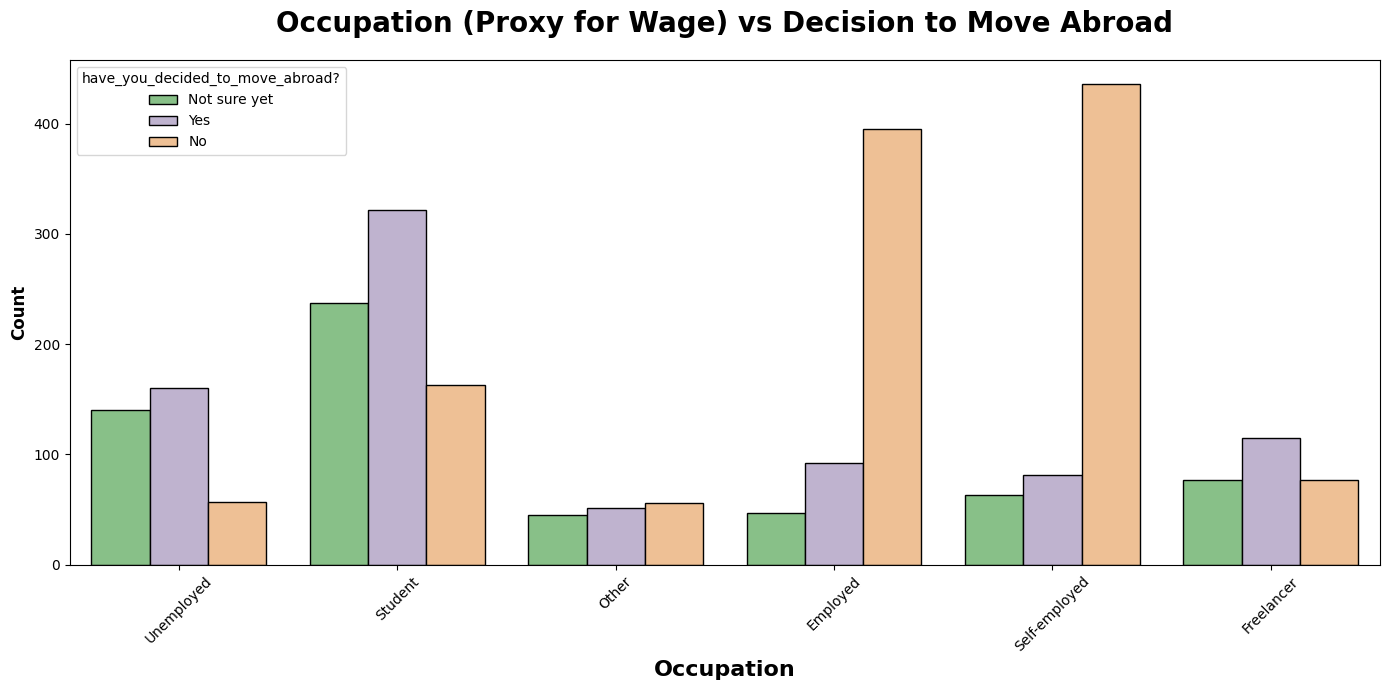

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# proxy for wage → occupation
feature = 'what_is_your_occupation?'
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

sns.countplot(
    x=feature,
    hue=target,
    data=df,
    edgecolor='k',
    palette='Accent'
)

plt.title("Occupation (Proxy for Wage) vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Occupation", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

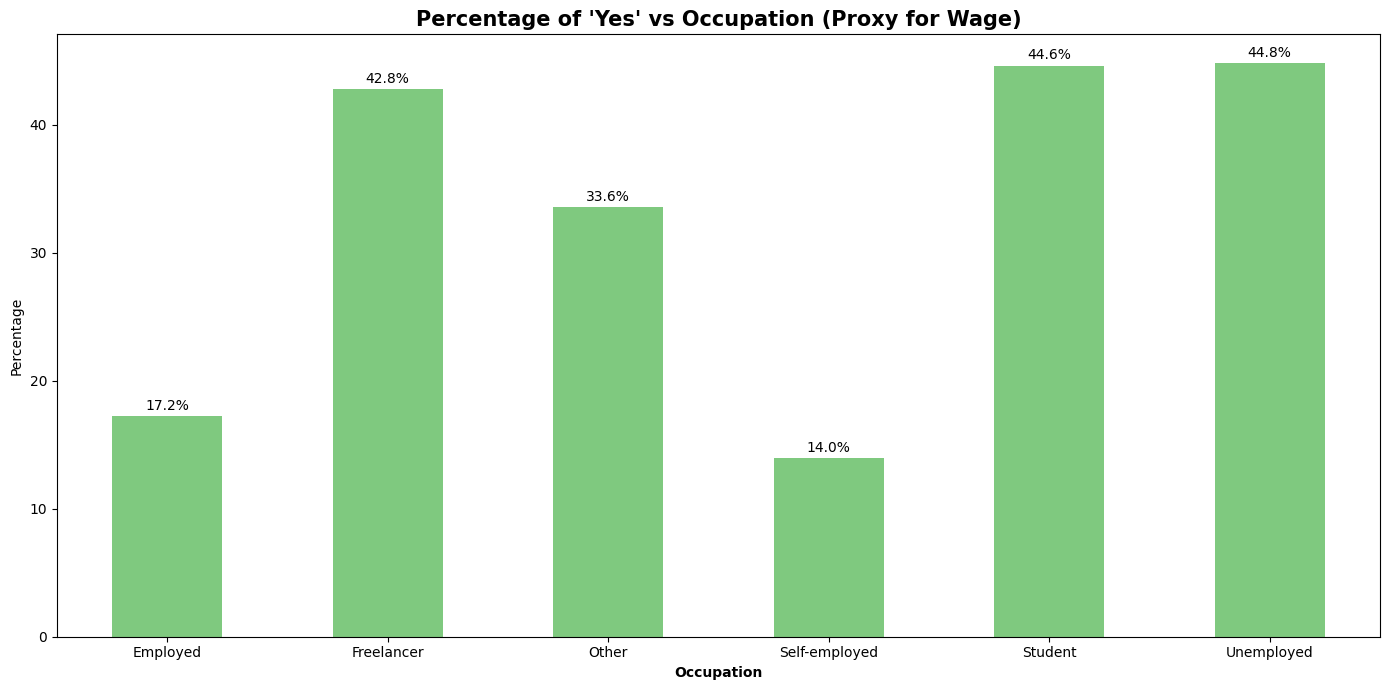

In [71]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
target = 'have_you_decided_to_move_abroad?'
feature = 'what_is_your_occupation?'   # proxy for wage

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes'][feature].value_counts() /
    df[feature].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of 'Yes' vs Occupation (Proxy for Wage)",
          fontsize=15, fontweight='bold')

# add labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Occupation', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

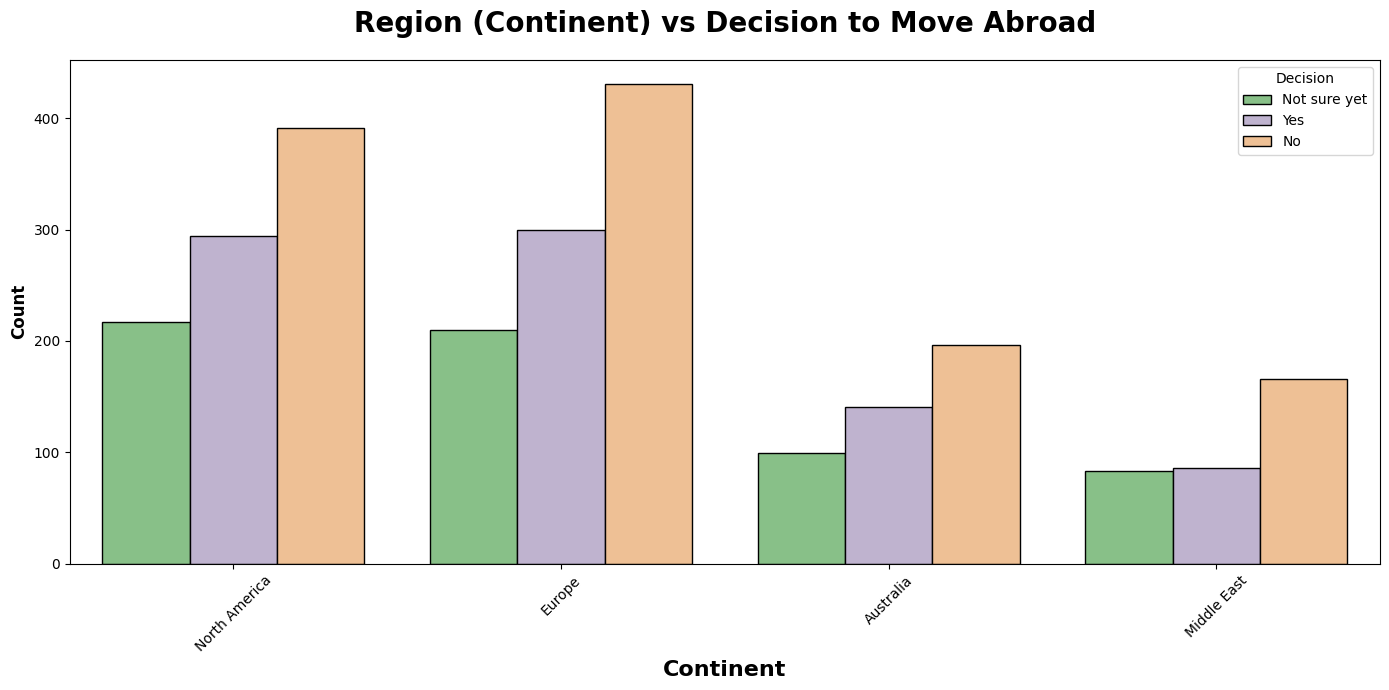

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# target column
target = 'have_you_decided_to_move_abroad?'

plt.figure(figsize=(14,7))

sns.countplot(
    x='continent',
    hue=target,
    data=df,
    edgecolor='k',
    palette='Accent'
)

plt.title("Region (Continent) vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Continent", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)

plt.xticks(rotation=45)
plt.legend(title="Decision", fancybox=True)

plt.tight_layout()
plt.show()

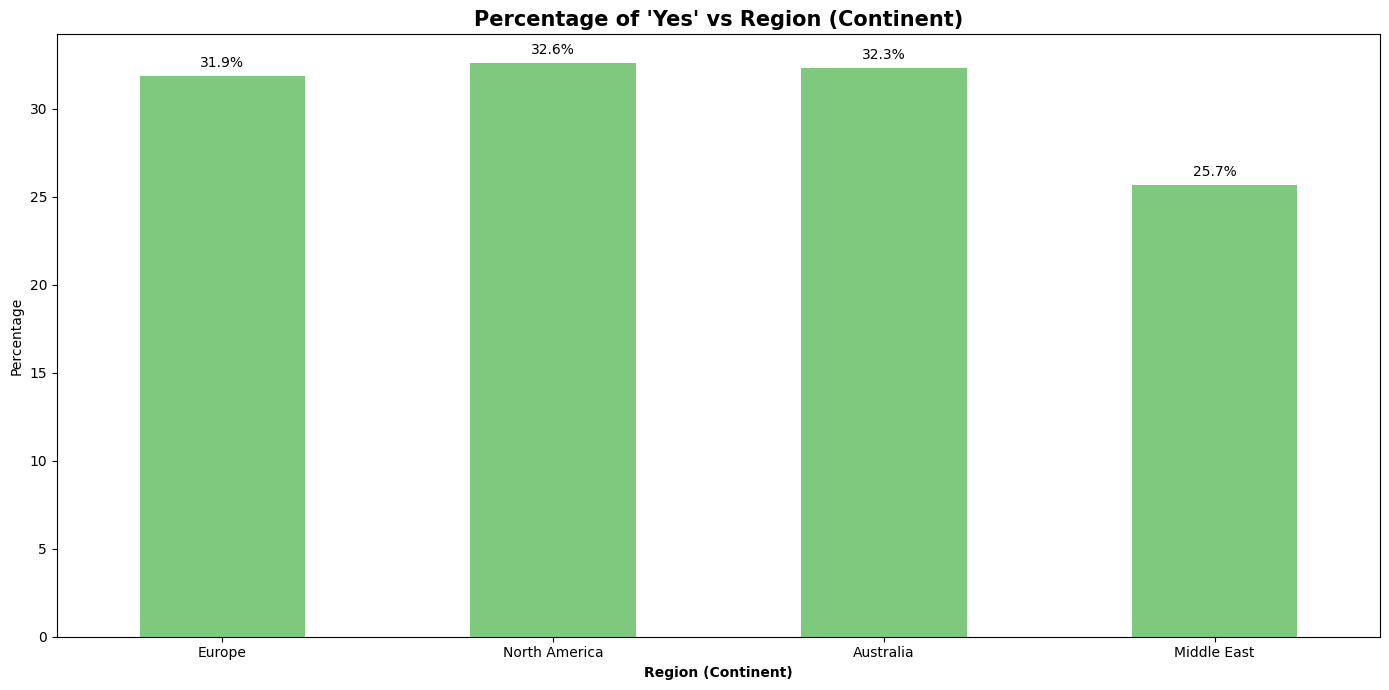

In [73]:
import matplotlib.pyplot as plt

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
target = 'have_you_decided_to_move_abroad?'
feature = 'continent'   # region proxy

plt.figure(figsize=(14,7))

# percentage of "Yes"
percentage = (
    df[df[target] == 'Yes'][feature].value_counts() /
    df[feature].value_counts()
) * 100

percentage.plot(kind='bar', colormap='Accent')

plt.title("Percentage of 'Yes' vs Region (Continent)",
          fontsize=15, fontweight='bold')

# add labels
for i, val in enumerate(percentage):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center')

plt.xlabel('Region (Continent)', fontweight='bold')
plt.ylabel('Percentage')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [74]:
# clean columns
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

feature = 'what_is_your_occupation?'   # proxy
target = 'have_you_decided_to_move_abroad?'

df.groupby(feature)[target] \
  .value_counts(normalize=True) \
  .mul(100)

what_is_your_occupation?  have_you_decided_to_move_abroad?
Employed                  No                                  73.970037
                          Yes                                 17.228464
                          Not sure yet                         8.801498
Freelancer                Yes                                 42.750929
                          No                                  28.624535
                          Not sure yet                        28.624535
Other                     No                                  36.842105
                          Yes                                 33.552632
                          Not sure yet                        29.605263
Self-employed             No                                  75.172414
                          Yes                                 13.965517
                          Not sure yet                        10.862069
Student                   Yes                                 44.598338
     

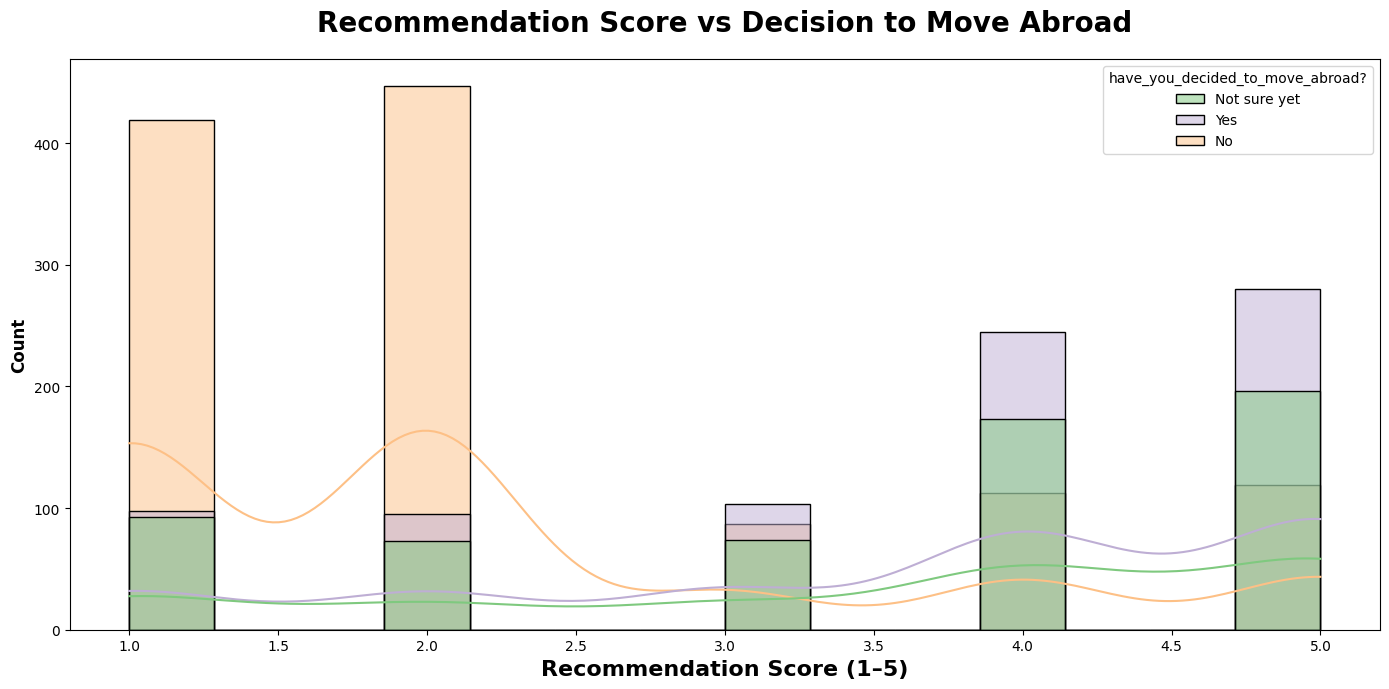

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
target = 'have_you_decided_to_move_abroad?'
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

plt.figure(figsize=(14,7))

sns.histplot(
    data=df,
    x=num_feature,
    hue=target,
    kde=True,
    palette='Accent'
)

plt.title("Recommendation Score vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Recommendation Score (1–5)", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)

plt.tight_layout()
plt.show()

In [76]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'what_is_your_occupation?'   # proxy for education
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

print('Average Recommendation Score based on Occupation (Proxy for Education)')

df.groupby(feature)[num_feature] \
  .mean() \
  .to_frame(name='avg_score') \
  .sort_values(by='avg_score', ascending=False)

Average Recommendation Score based on Occupation (Proxy for Education)


,avg_score
what_is_your_occupation?,
Unemployed,3.778711
Student,3.620499
Freelancer,3.412639
Other,3.282895
Employed,2.132959
Self-employed,2.082759


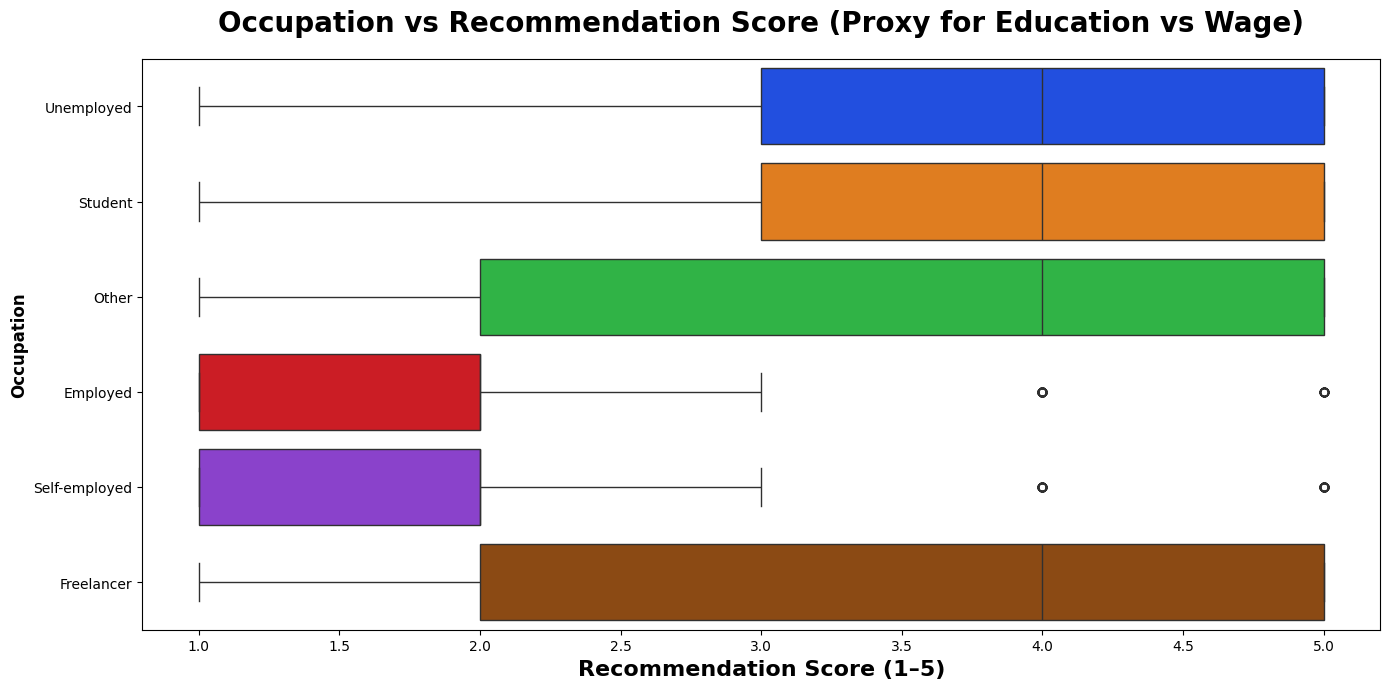

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'what_is_your_occupation?'   # proxy for education
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

plt.figure(figsize=(14,7))

sns.boxplot(
    y=feature,
    x=num_feature,
    data=df,
    palette='bright'
)

plt.title("Occupation vs Recommendation Score (Proxy for Education vs Wage)",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Recommendation Score (1–5)", weight="bold", fontsize=16)
plt.ylabel("Occupation", weight="bold", fontsize=12)

plt.tight_layout()
plt.show()

In [78]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define columns
feature = 'what_is_your_occupation?'   # proxy for job experience
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

print('Median Recommendation Score based on Occupation (Proxy for Job Experience)')

df.groupby(feature)[num_feature] \
  .median() \
  .to_frame(name='median_score') \
  .sort_values(by='median_score', ascending=False)

Median Recommendation Score based on Occupation (Proxy for Job Experience)


,median_score
what_is_your_occupation?,
Freelancer,4.0
Other,4.0
Student,4.0
Unemployed,4.0
Employed,2.0
Self-employed,2.0


In [79]:
# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define numeric proxy
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

print('Average Recommendation Score based on Continent')

df.groupby('continent')[num_feature] \
  .mean() \
  .to_frame(name='avg_score') \
  .sort_values(by='avg_score', ascending=False)

Average Recommendation Score based on Continent


,avg_score
continent,
Europe,2.978746
Middle East,2.970149
North America,2.963415
Australia,2.880734


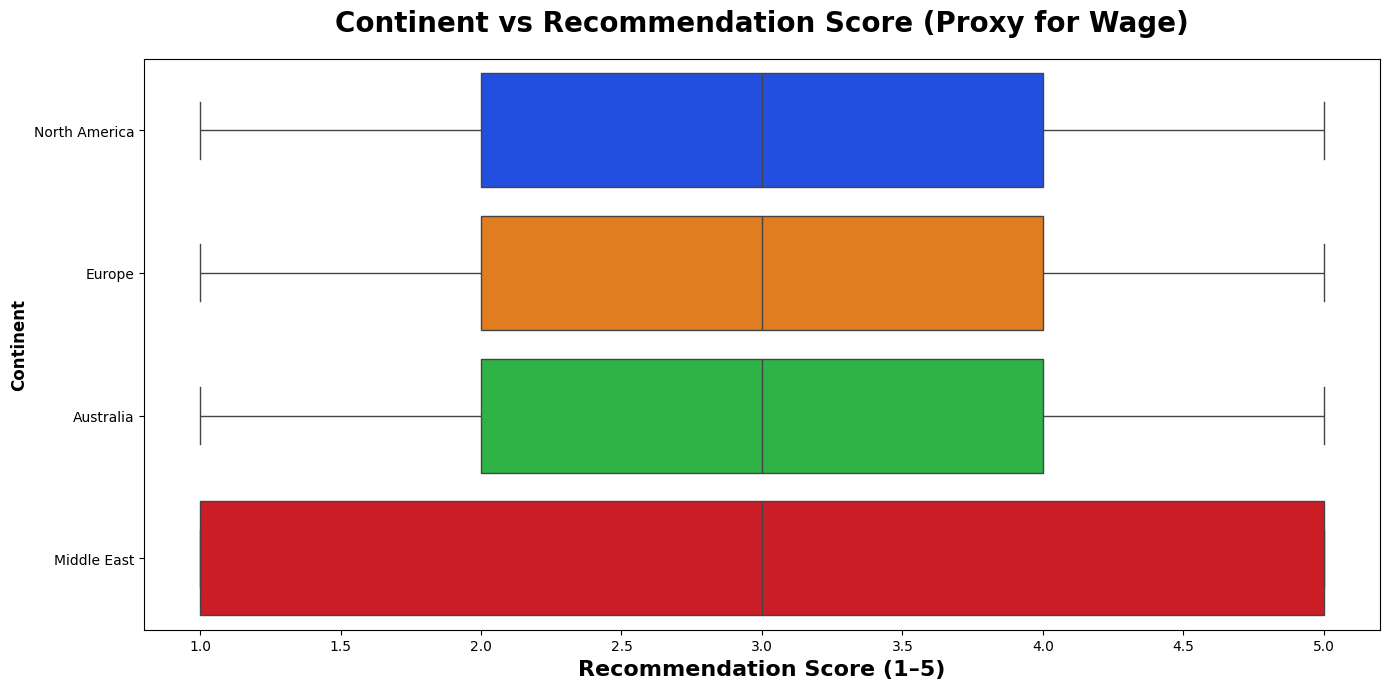

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# numeric proxy (instead of wage)
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

plt.figure(figsize=(14,7))

sns.boxplot(
    y='continent',
    x=num_feature,
    data=df,
    palette='bright'
)

plt.title("Continent vs Recommendation Score (Proxy for Wage)",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Recommendation Score (1–5)", weight="bold", fontsize=16)
plt.ylabel("Continent", weight="bold", fontsize=12)

plt.tight_layout()
plt.show()

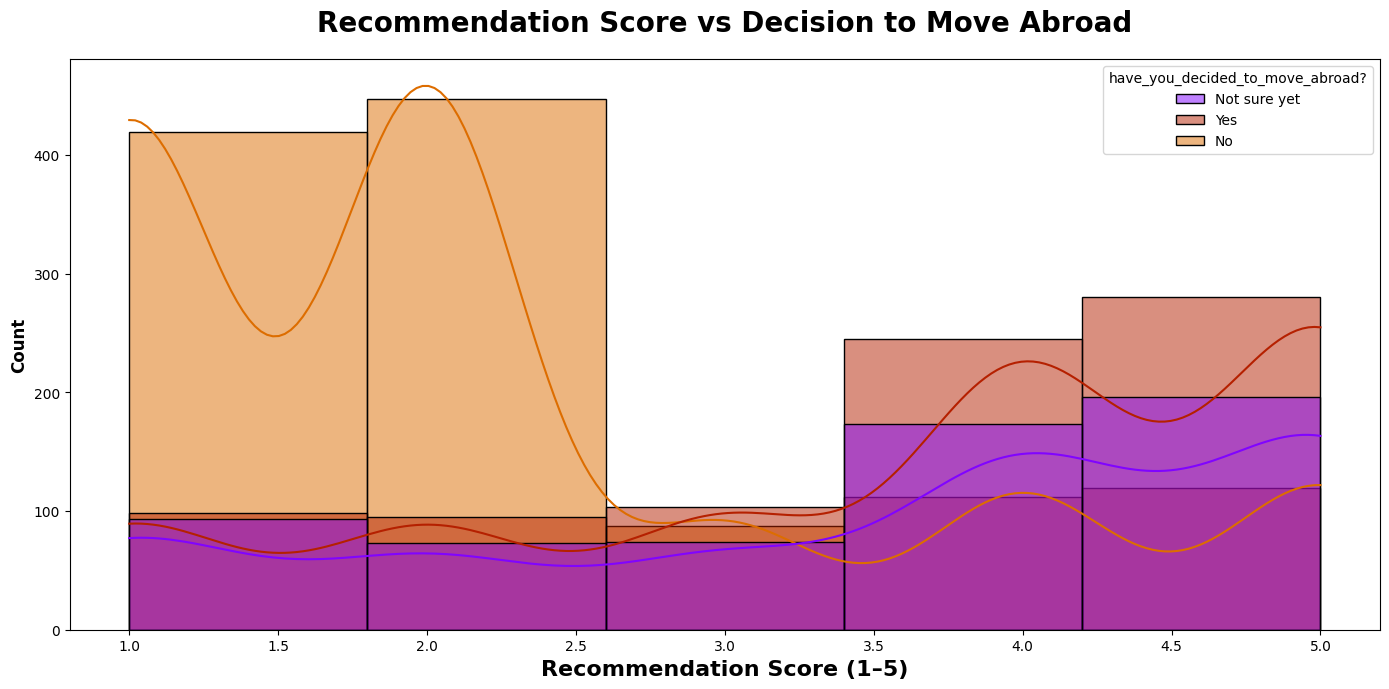

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# define target + numeric feature
target = 'have_you_decided_to_move_abroad?'
num_feature = 'how_likely_are_you_to_recommend_going_abroad_to_others_in_your_age_group?_(rate_on_a_scale_of_1_to_5,_where_1_is_very_unlikely_and_5_is_very_likely).'

# ensure numeric
df[num_feature] = pd.to_numeric(df[num_feature], errors='coerce')

plt.figure(figsize=(14,7))

sns.histplot(
    data=df,
    x=num_feature,
    hue=target,
    bins=5,
    kde=True,
    palette='gnuplot'
)

plt.title("Recommendation Score vs Decision to Move Abroad",
          weight="bold", fontsize=20, pad=20)

plt.xlabel("Recommendation Score (1–5)", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)

plt.tight_layout()
plt.show()